# Combined Round 1 + Round 2 Pricing Plots
6 trading days total (3 from R1, 3 from R2). R1/R2 day labels overlap but the underlying realizations differ (mean per-tick diff ~36), so we treat all 6 as distinct consecutive days.

Ordering used: `R1 day -2 → R1 day -1 → R1 day 0 → R2 day -1 → R2 day 0 → R2 day 1`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True

R1 = '/Users/markiejr/Propserity_4/data/ROUND1/ROUND1_DATA'
R2 = '/Users/markiejr/Propserity_4/data/ROUND2/ROUND_2_DATA'

# Load 6 days sequentially, each gets a unique `seq_day` index 0..5
specs = [
    ('R1', R1, -2), ('R1', R1, -1), ('R1', R1, 0),
    ('R2', R2, -1), ('R2', R2, 0), ('R2', R2, 1),
]

frames = []
for i, (rnd, base, d) in enumerate(specs):
    df = pd.read_csv(f'{base}/prices_round_{rnd[1]}_day_{d}.csv', sep=';')
    df['round'] = rnd
    df['seq_day'] = i
    df['label'] = f'{rnd} d{d:+d}'
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)

# Clean mid price (recompute from best bid/ask, drop empty-book ticks)
prices['mid'] = np.where(
    prices['bid_price_1'].notna() & prices['ask_price_1'].notna(),
    (prices['bid_price_1'] + prices['ask_price_1']) / 2,
    prices['mid_price'],
)
prices = prices[prices['mid'] > 0].copy()

# Global timestamp — each day gets 1M ticks of space
prices['global_ts'] = prices['seq_day'] * 1_000_000 + prices['timestamp']

print(f'Rows: {len(prices):,}')
print(prices.groupby(['seq_day','label','product']).size().unstack())

Rows: 119,797
product         ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
seq_day label                                          
0       R1 d-2               9982                  9984
1       R1 d-1               9983                  9983
2       R1 d+0               9986                  9979
3       R2 d-1               9985                  9987
4       R2 d+0               9984                  9982
5       R2 d+1               9978                  9984


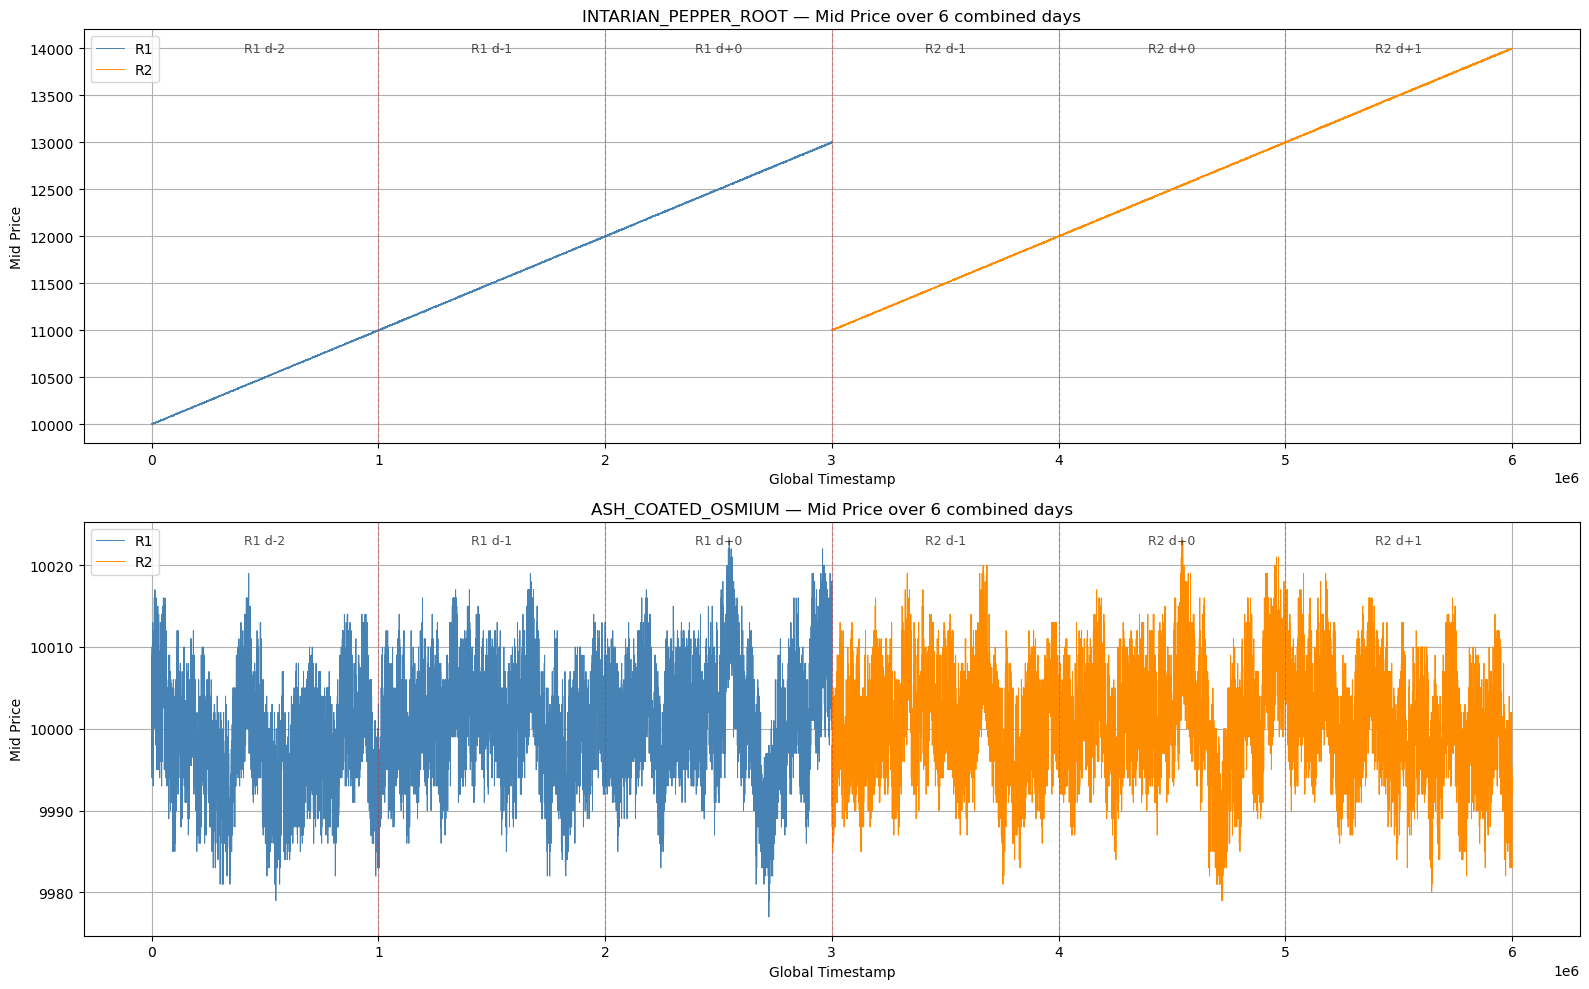


=== Per-day summary ===
                                       first     last      mean     std      min      max
seq_day label  product                                                                   
0       R1 d-2 ASH_COATED_OSMIUM     10010.0   9993.5   9998.17    5.22   9979.0  10019.0
               INTARIAN_PEPPER_ROOT   9998.5  11001.5  10499.96  288.72   9998.5  11003.0
1       R1 d-1 ASH_COATED_OSMIUM     10003.0  10002.0  10000.83    4.45   9982.0  10019.0
               INTARIAN_PEPPER_ROOT  10998.5  11998.0  11500.03  288.67  10995.0  12006.0
2       R1 d+0 ASH_COATED_OSMIUM     10013.0  10007.0  10001.61    5.68   9977.0  10023.0
               INTARIAN_PEPPER_ROOT  11998.5  13000.0  12500.17  288.73  11994.0  13007.0
3       R2 d-1 ASH_COATED_OSMIUM      9991.0  10002.0  10000.83    4.47   9981.0  10020.0
               INTARIAN_PEPPER_ROOT  11001.5  11999.5  11500.12  288.65  10998.0  12001.5
4       R2 d+0 ASH_COATED_OSMIUM     10003.0  10008.0  10001.61    5.66   9

In [2]:
products = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

day_boundaries = [i * 1_000_000 for i in range(1, 6)]
round_colors = {'R1': 'steelblue', 'R2': 'darkorange'}

for ax, product in zip(axes, products):
    for rnd, color in round_colors.items():
        sub = prices[(prices['product'] == product) & (prices['round'] == rnd)]
        ax.plot(sub['global_ts'], sub['mid'], linewidth=0.7, color=color, label=f'{rnd}')

    for b in day_boundaries:
        ax.axvline(b, color='red', linestyle='--', alpha=0.35, linewidth=0.8)

    # Day labels across the top (axis-fraction y via blended transform)
    for i, (rnd, _, d) in enumerate(specs):
        ax.text(i * 1_000_000 + 500_000, 0.97, f'{rnd} d{d:+d}',
                ha='center', va='top', fontsize=9, alpha=0.7,
                transform=ax.get_xaxis_transform())

    ax.set_title(f'{product} — Mid Price over 6 combined days')
    ax.set_xlabel('Global Timestamp')
    ax.set_ylabel('Mid Price')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Per-day summary
summary = (prices.groupby(['seq_day','label','product'])['mid']
                 .agg(['first','last','mean','std','min','max'])
                 .round(2))
print('\n=== Per-day summary ===')
print(summary.to_string())

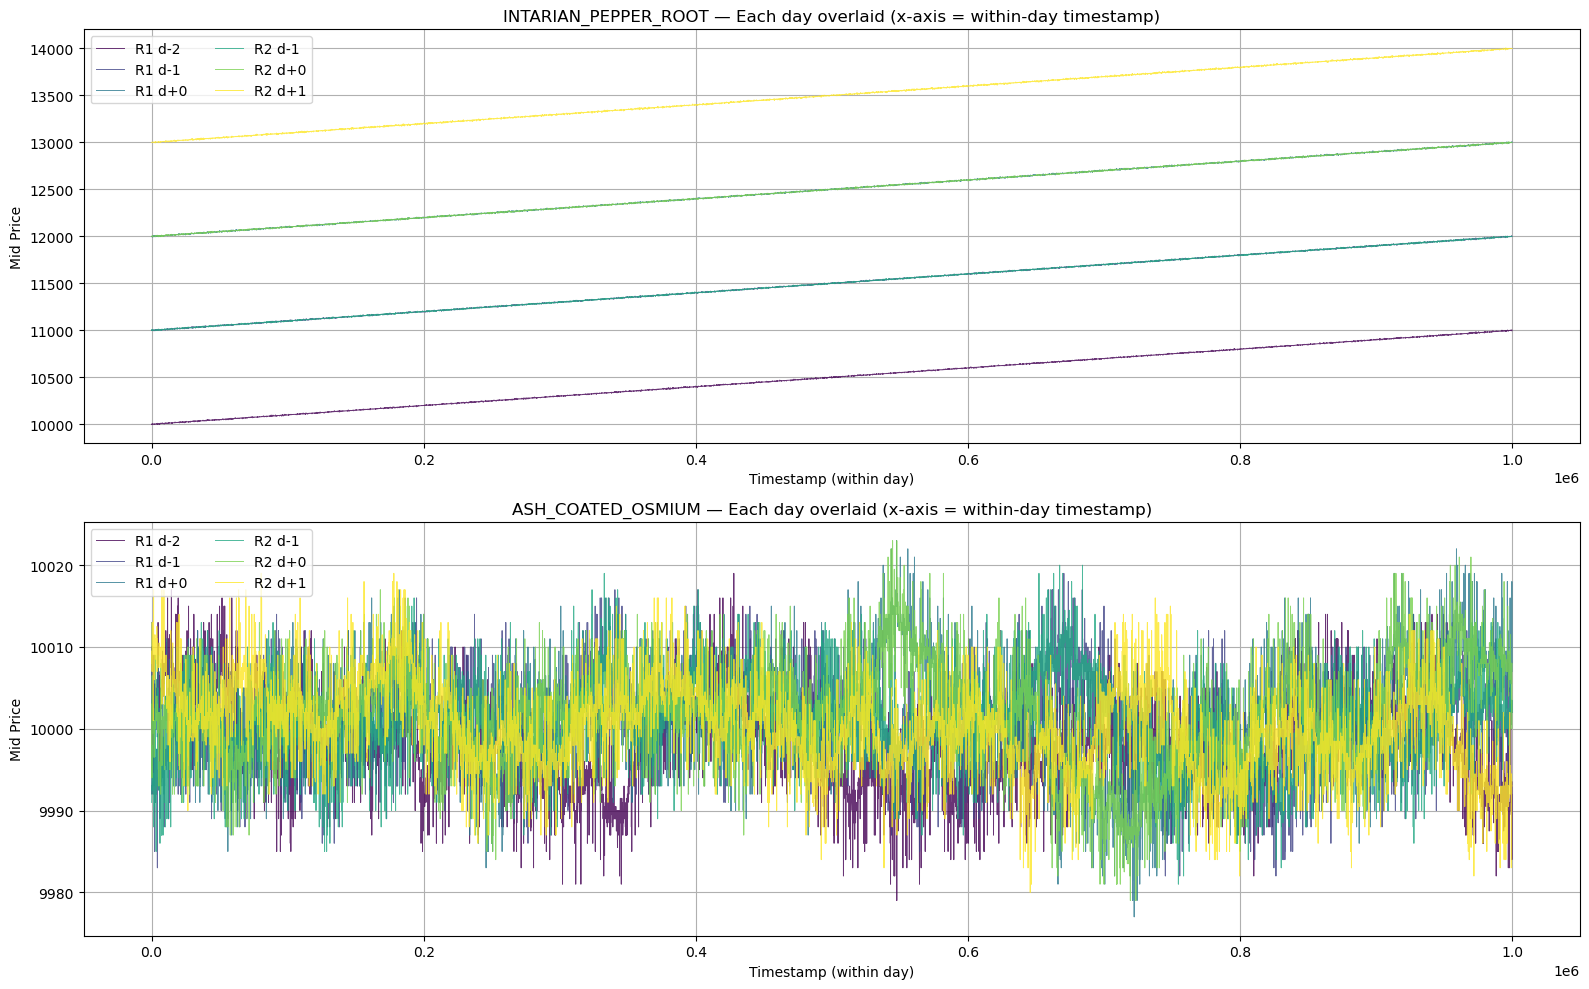

In [3]:
# Overlay view — all 6 days starting from t=0 to compare shapes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
day_colors = plt.cm.viridis(np.linspace(0, 1, len(specs)))

for ax, product in zip(axes, products):
    for i, (rnd, _, d) in enumerate(specs):
        sub = prices[(prices['product'] == product) & (prices['seq_day'] == i)]
        ax.plot(sub['timestamp'], sub['mid'], linewidth=0.7, alpha=0.8,
                color=day_colors[i], label=f'{rnd} d{d:+d}')
    ax.set_title(f'{product} — Each day overlaid (x-axis = within-day timestamp)')
    ax.set_xlabel('Timestamp (within day)')
    ax.set_ylabel('Mid Price')
    ax.legend(loc='upper left', ncol=2)

plt.tight_layout()
plt.show()